In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/featured_data.csv")

In [3]:
features = [
    "Store",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Week",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Rolling_Mean_4",
    "Rolling_Std_4"
]

In [4]:
X = df[features]

y = df["Weekly_Sales"]

In [5]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [6]:
from sklearn.ensemble import RandomForestRegressor

In [7]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [8]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
rf_pred = rf_model.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:
rf_mae = mean_absolute_error(y_test, rf_pred)
print("Random Forest MAE:", rf_mae)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
print("Random Forest RMSE:", rf_rmse)
rf_r2 = r2_score(y_test, rf_pred)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 33693.36996227018
Random Forest RMSE: 67023.93077630579
Random Forest R²: 0.9706195540947024


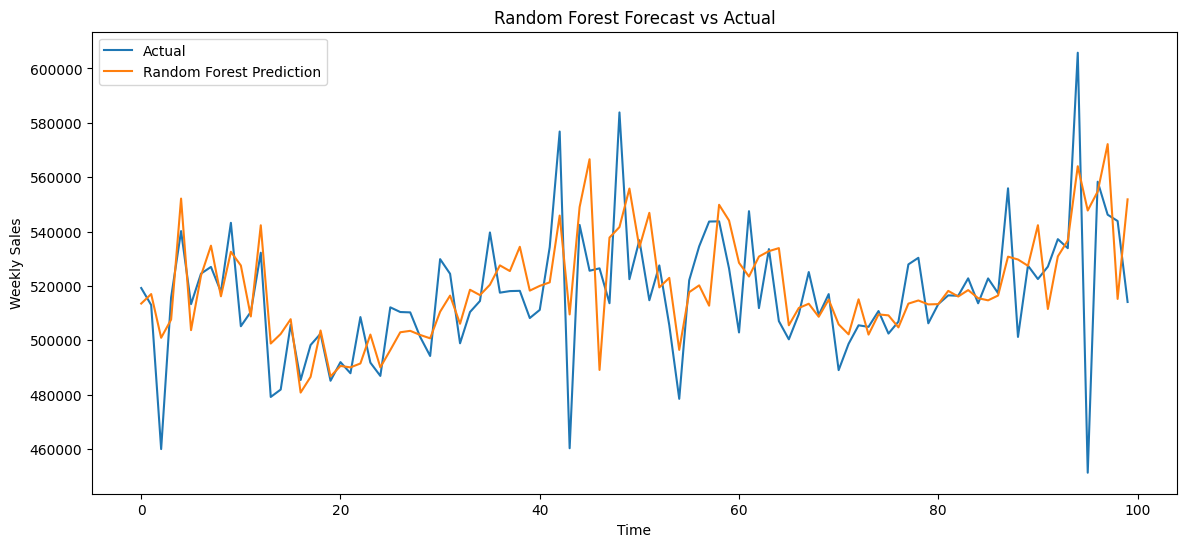

In [12]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(rf_pred[:100], label="Random Forest Prediction")

plt.title("Random Forest Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Weekly Sales")

plt.legend()

plt.show()

In [13]:
importance = rf_model.feature_importances_

In [14]:
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

In [15]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [16]:
feature_importance_df

,Feature,Importance
12,Rolling_Mean_4,0.938120
9,Lag_1,0.019106
13,Rolling_Std_4,0.015001
8,Week,0.010576
11,Lag_4,0.007578
10,Lag_2,0.004200
2,Temperature,0.001017
4,CPI,0.000906
1,Holiday_Flag,0.000880
3,Fuel_Price,0.000700


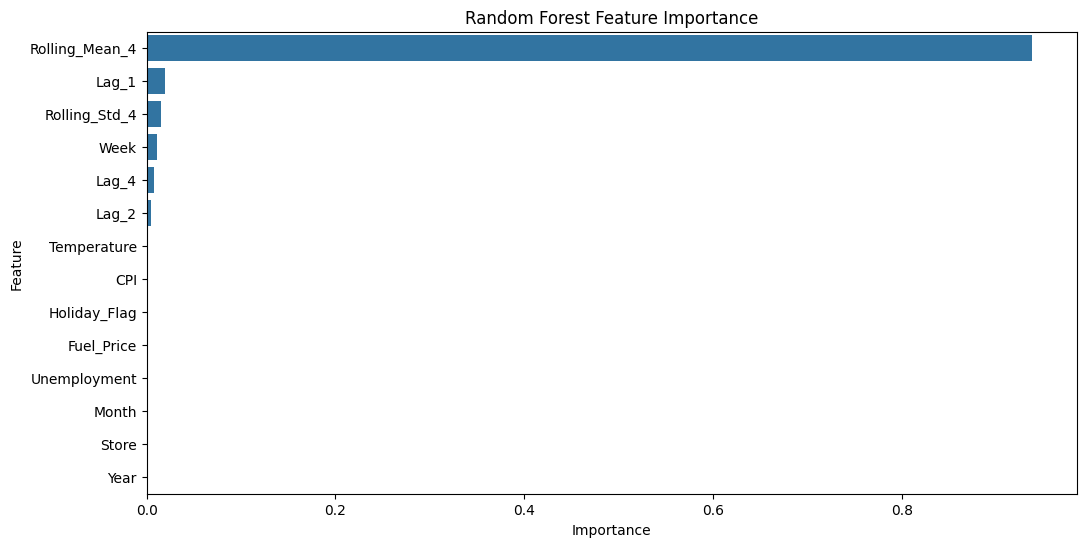

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()